In [1]:
from pathlib import Path
from itertools import permutations

import pandas as pd


# Raíz del proyecto.
# Si el notebook está dentro de /notebooks, subimos un nivel.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw" / "instacart"

ORDER_PRODUCTS_PRIOR_PATH = RAW_DATA_DIR / "order_products__prior.csv"
PRODUCTS_PATH = RAW_DATA_DIR / "products.csv"
AISLES_PATH = RAW_DATA_DIR / "aisles.csv"
DEPARTMENTS_PATH = RAW_DATA_DIR / "departments.csv"

print(PROJECT_ROOT)

c:\Users\Lenovo\Desktop\retail-recommender-mlops


In [2]:
# Para aprendizaje, no necesitamos todo el dataset.
# Tomamos máximo 200,000 líneas de productos comprados.
# Cada fila representa un producto dentro de una orden.

MAX_ROWS = 200_000

order_products = pd.read_csv(
    ORDER_PRODUCTS_PRIOR_PATH,
    nrows=MAX_ROWS
)

print(order_products.shape)
order_products.head()

(200000, 4)


,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


In [3]:
#Catalogo de productos
products = pd.read_csv(PRODUCTS_PATH)
aisles = pd.read_csv(AISLES_PATH)
departments = pd.read_csv(DEPARTMENTS_PATH)

In [7]:
products_enriched = (
    products
    .merge(aisles, on="aisle_id", how="left")
    .merge(departments, on="department_id", how="left")
)

products_enriched.head()

,product_id,product_name,aisle_id,department_id,aisle,department
0,1,Chocolate Sandwich Cookies,61,19,cookies cakes,snacks
1,2,All-Seasons Salt,104,13,spices seasonings,pantry
2,3,Robust Golden Unsweetened Oolong Tea,94,7,tea,beverages
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1,frozen meals,frozen
4,5,Green Chile Anytime Sauce,5,13,marinades meat preparation,pantry


In [9]:
#Unir compras con nombre de productos
df = (
    order_products
    .merge(
        products_enriched,
        on="product_id",
        how="left"
    )
)

print(df.shape)
df.head(20)

(200000, 9)


,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,department
0,2,33120,1,1,Organic Egg Whites,86,16,eggs,dairy eggs
1,2,28985,2,1,Michigan Organic Kale,83,4,fresh vegetables,produce
2,2,9327,3,0,Garlic Powder,104,13,spices seasonings,pantry
3,2,45918,4,1,Coconut Butter,19,13,oils vinegars,pantry
4,2,30035,5,0,Natural Sweetener,17,13,baking ingredients,pantry
5,2,17794,6,1,Carrots,83,4,fresh vegetables,produce
6,2,40141,7,1,Original Unflavored Gelatine Mix,105,13,doughs gelatins bake mixes,pantry
7,2,1819,8,1,All Natural No Stir Creamy Almond Butter,88,13,spreads,pantry
8,2,43668,9,0,Classic Blend Cole Slaw,123,4,packaged vegetables fruits,produce
9,3,33754,1,1,Total 2% with Strawberry Lowfat Greek Strained...,120,16,yogurt,dairy eggs


In [10]:
## Una canasta es una orden con varios productos. Para cada orden, obtenemos la lista de productos comprados.

# Agrupamos productos por orden.
# Cada order_id representa una compra/canasta.

baskets = (
    df
    .groupby("order_id")
    .agg(
        product_ids=("product_id", list),
        product_names=("product_name", list),
        basket_size=("product_id", "count")
    )
    .reset_index()
)

print(baskets.shape)
baskets.head()

(19850, 4)


,order_id,product_ids,product_names,basket_size
0,2,"[33120, 28985, 9327, 45918, 30035, 17794, 4014...","[Organic Egg Whites, Michigan Organic Kale, Ga...",9
1,3,"[33754, 24838, 17704, 21903, 17668, 46667, 174...",[Total 2% with Strawberry Lowfat Greek Straine...,8
2,4,"[46842, 26434, 39758, 27761, 10054, 21351, 225...","[Plain Pre-Sliced Bagels, Honey/Lemon Cough Dr...",13
3,5,"[13176, 15005, 47329, 27966, 23909, 48370, 132...","[Bag of Organic Bananas, Just Crisp, Parmesan,...",26
4,6,"[40462, 15873, 41897]","[Cleanse, Dryer Sheets Geranium Scent, Clean D...",3


array([[<Axes: title={'center': 'basket_size'}>]], dtype=object)

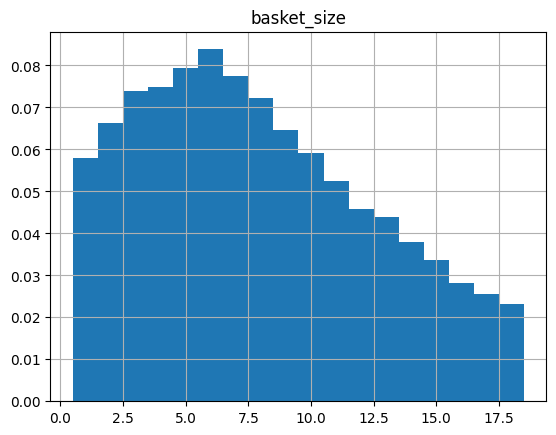

In [11]:
import numpy as np
baskets.hist(column="basket_size", bins=np.arange(1, 20) - 0.5, density=True)

In [13]:
baskets["basket_size"].describe()

count    19850.000000
mean        10.075567
std          7.495197
min          1.000000
25%          5.000000
50%          8.000000
75%         14.000000
max         68.000000
Name: basket_size, dtype: float64

In [14]:
# Para entender el algoritmo, usamos canastas manejables.
# Eliminamos canastas de 1 producto porque no generan pares.
# Limitamos a máximo 10 productos por orden para evitar demasiadas combinaciones.

baskets_small = baskets[
    (baskets["basket_size"] >= 2) &
    (baskets["basket_size"] <= 10)
].copy()

print(baskets_small.shape)
baskets_small.head()

(11331, 4)


,order_id,product_ids,product_names,basket_size
0,2,"[33120, 28985, 9327, 45918, 30035, 17794, 4014...","[Organic Egg Whites, Michigan Organic Kale, Ga...",9
1,3,"[33754, 24838, 17704, 21903, 17668, 46667, 174...",[Total 2% with Strawberry Lowfat Greek Straine...,8
4,6,"[40462, 15873, 41897]","[Cleanse, Dryer Sheets Geranium Scent, Clean D...",3
5,7,"[34050, 46802]","[Orange Juice, Pineapple Chunks]",2
9,11,"[30162, 27085, 5994, 1313, 31506]","[Teriyaki & Pineapple Chicken Meatballs, Mango...",5


In [15]:
#canasta especifica
sample_basket = baskets_small.iloc[0]

print("order_id:", sample_basket["order_id"])
print("basket_size:", sample_basket["basket_size"])
print("products:")

for product in sample_basket["product_names"]:
    print("-", product)

order_id: 2
basket_size: 9
products:
- Organic Egg Whites
- Michigan Organic Kale
- Garlic Powder
- Coconut Butter
- Natural Sweetener
- Carrots
- Original Unflavored Gelatine Mix
- All Natural No Stir Creamy Almond Butter
- Classic Blend Cole Slaw


In [16]:
#Crear pares de productos comprados juntos
# Para cada canasta, generamos todas las combinaciones posibles de productos.

# Si una orden tiene:
# [A, B, C]
#
# Generamos pares dirigidos:
# A -> B
# A -> C
# B -> A
# B -> C
# C -> A
# C -> B
#
# Es decir: si el cliente tiene A, podemos recomendar B o C.

product_ids = sample_basket["product_ids"]

pairs = list(permutations(product_ids, 2))

pairs[:10], len(pairs)

([(33120, 28985),
  (33120, 9327),
  (33120, 45918),
  (33120, 30035),
  (33120, 17794),
  (33120, 40141),
  (33120, 1819),
  (33120, 43668),
  (28985, 33120),
  (28985, 9327)],
 72)

In [23]:
#Convertir pares a DataFrame

pairs_df = pd.DataFrame(
    pairs,
    columns=["source_product_id", "recommended_product_id"]
)

pairs_df.head(20)

,source_product_id,recommended_product_id
0,33120,28985
1,33120,9327
2,33120,45918
3,33120,30035
4,33120,17794
5,33120,40141
6,33120,1819
7,33120,43668
8,28985,33120
9,28985,9327


In [25]:
#Pares con nombres de productos
pairs_named = (
    pairs_df
    .merge(
        products[["product_id", "product_name"]],
        left_on="source_product_id",
        right_on="product_id",
        how="left"
    )
    .rename(columns={"product_name": "source_product_name"})
    .drop(columns=["product_id"])
    .merge(
        products[["product_id", "product_name"]],
        left_on="recommended_product_id",
        right_on="product_id",
        how="left"
    )
    .rename(columns={"product_name": "recommended_product_name"})
    .drop(columns=["product_id"])
)

pairs_named.head(20)

,source_product_id,recommended_product_id,source_product_name,recommended_product_name
0,33120,28985,Organic Egg Whites,Michigan Organic Kale
1,33120,9327,Organic Egg Whites,Garlic Powder
2,33120,45918,Organic Egg Whites,Coconut Butter
3,33120,30035,Organic Egg Whites,Natural Sweetener
4,33120,17794,Organic Egg Whites,Carrots
5,33120,40141,Organic Egg Whites,Original Unflavored Gelatine Mix
6,33120,1819,Organic Egg Whites,All Natural No Stir Creamy Almond Butter
7,33120,43668,Organic Egg Whites,Classic Blend Cole Slaw
8,28985,33120,Michigan Organic Kale,Organic Egg Whites
9,28985,9327,Michigan Organic Kale,Garlic Powder


In [27]:
#Generar pares para varias canastas

# Para practicar, no usamos todas las canastas.
# Usamos 5,000 órdenes como muestra didáctica.
# Puedes subir este número después.

MAX_ORDERS_FOR_TRAINING = 5_000

training_baskets = baskets_small.head(MAX_ORDERS_FOR_TRAINING).copy()

all_pairs = []

for _, row in training_baskets.iterrows():
    order_id = row["order_id"]
    product_ids = row["product_ids"]
    
    # Genera pares dirigidos dentro de la misma orden.
    for source_product_id, recommended_product_id in permutations(product_ids, 2):
        all_pairs.append(
            {
                "order_id": order_id,
                "source_product_id": source_product_id,
                "recommended_product_id": recommended_product_id,
            }
        )

pairs_training = pd.DataFrame(all_pairs)

print(pairs_training.shape)
pairs_training.head()

(176328, 3)


,order_id,source_product_id,recommended_product_id
0,2,33120,28985
1,2,33120,9327
2,2,33120,45918
3,2,33120,30035
4,2,33120,17794


In [28]:
#Contar co-ocurrencias de pares

# La co-ocurrencia mide cuántas veces dos productos aparecen juntos.
#
# Ejemplo:
# Banana -> Organic Strawberries aparece 120 veces.
#
# Eso significa que en 120 órdenes donde estaba Banana,
# también estaba Organic Strawberries.

cooccurrence = (
    pairs_training
    .groupby(["source_product_id", "recommended_product_id"])
    .size()
    .reset_index(name="cooccurrence_count")
)

cooccurrence = cooccurrence.sort_values(
    "cooccurrence_count",
    ascending=False
)

cooccurrence.head(20)

,source_product_id,recommended_product_id,cooccurrence_count
151635,47209,13176,37
40269,13176,47209,37
78386,24852,21137,36
64958,21137,24852,36
68250,21903,13176,35
39558,13176,21903,35
64741,21137,13176,34
39530,13176,21137,34
79271,24852,45066,32
144890,45066,24852,32


In [29]:
# Necesitamos saber cuántas veces aparece cada producto base.
# Esto permite normalizar la co-ocurrencia.
#
# Si Banana aparece 1,000 veces y coocurre con Fresas 100 veces,
# score = 100 / 1000 = 0.10

source_frequency = (
    pairs_training[["order_id", "source_product_id"]]
    .drop_duplicates()
    .groupby("source_product_id")
    .size()
    .reset_index(name="source_product_frequency")
)

source_frequency.head()

,source_product_id,source_product_frequency
0,1,2
1,10,2
2,23,1
3,25,1
4,28,5


In [30]:
#Calcular score de recomendación
# El score de recomendación se calcula como:    
# score = co-ocurrencia / frecuencia del producto base

recommendations = (
    cooccurrence
    .merge(source_frequency, on="source_product_id", how="left")
)

recommendations["score"] = (
    recommendations["cooccurrence_count"] /
    recommendations["source_product_frequency"]
)

recommendations = recommendations.sort_values(
    ["source_product_id", "score", "cooccurrence_count"],
    ascending=[True, False, False]
)

recommendations.head(20)

,source_product_id,recommended_product_id,cooccurrence_count,source_product_frequency,score
8718,1,14161,1,2,0.5
8722,1,9076,1,2,0.5
8723,1,19972,1,2,0.5
160580,1,27839,1,2,0.5
160594,1,16797,1,2,0.5
160600,1,4210,1,2,0.5
160601,1,8596,1,2,0.5
160607,1,48907,1,2,0.5
160608,1,43962,1,2,0.5
160609,1,43352,1,2,0.5


In [31]:
#Crear ranking de recomendaciones top 10 productos
# Para cada producto base, queremos las 10 recomendaciones mejor puntuadas.

recommendations["rank"] = (
    recommendations
    .groupby("source_product_id")["score"]
    .rank(method="first", ascending=False)
)

top_recommendations = recommendations[
    recommendations["rank"] <= 10
].copy()

top_recommendations.head(20)

,source_product_id,recommended_product_id,cooccurrence_count,source_product_frequency,score,rank
8718,1,14161,1,2,0.5,1.0
8722,1,9076,1,2,0.5,2.0
8723,1,19972,1,2,0.5,3.0
160580,1,27839,1,2,0.5,4.0
160594,1,16797,1,2,0.5,5.0
160600,1,4210,1,2,0.5,6.0
160601,1,8596,1,2,0.5,7.0
160607,1,48907,1,2,0.5,8.0
160608,1,43962,1,2,0.5,9.0
160609,1,43352,1,2,0.5,10.0


In [47]:
#top_recommendations.groupby("source_product_id")['recommended_product_id'].apply(list).head()

In [48]:
#Agregar nombres de productos a recomendaciones

top_recommendations_named = (
    top_recommendations
    .merge(
        products[["product_id", "product_name"]],
        left_on="source_product_id",
        right_on="product_id",
        how="left"
    )
    .rename(columns={"product_name": "source_product_name"})
    .drop(columns=["product_id"])
    .merge(
        products[["product_id", "product_name"]],
        left_on="recommended_product_id",
        right_on="product_id",
        how="left"
    )
    .rename(columns={"product_name": "recommended_product_name"})
    .drop(columns=["product_id"])
)

top_recommendations_named.head(30)

,source_product_id,recommended_product_id,cooccurrence_count,source_product_frequency,score,rank,source_product_name,recommended_product_name
0,1,14161,1,2,0.5,1.0,Chocolate Sandwich Cookies,Kiwi
1,1,9076,1,2,0.5,2.0,Chocolate Sandwich Cookies,Blueberries
2,1,19972,1,2,0.5,3.0,Chocolate Sandwich Cookies,Semi-Sweet Chocolate Morsels
3,1,27839,1,2,0.5,4.0,Chocolate Sandwich Cookies,49 Flavors Jelly Belly Jelly Beans
4,1,16797,1,2,0.5,5.0,Chocolate Sandwich Cookies,Strawberries
5,1,4210,1,2,0.5,6.0,Chocolate Sandwich Cookies,Whole Milk
6,1,8596,1,2,0.5,7.0,Chocolate Sandwich Cookies,Lemonade Drink Mix
7,1,48907,1,2,0.5,8.0,Chocolate Sandwich Cookies,Garden Salad Mix
8,1,43962,1,2,0.5,9.0,Chocolate Sandwich Cookies,Coleslaw
9,1,43352,1,2,0.5,10.0,Chocolate Sandwich Cookies,Raspberries


In [49]:
#Probar recomendacion para banana

# En Instacart, product_id 24852 suele ser Banana.

banana_id = 24852

banana_recommendations = top_recommendations_named[
    top_recommendations_named["source_product_id"] == banana_id
].sort_values("rank")

banana_recommendations[
    [
        "source_product_name",
        "recommended_product_name",
        "cooccurrence_count",
        "source_product_frequency",
        "score",
        "rank",
    ]
]

,source_product_name,recommended_product_name,cooccurrence_count,source_product_frequency,score,rank
34364,Banana,Organic Strawberries,36,494,0.072874,1.0
34365,Banana,Honeycrisp Apple,32,494,0.064777,2.0
34366,Banana,Organic Avocado,31,494,0.062753,3.0
34367,Banana,Strawberries,28,494,0.056680,4.0
34368,Banana,Organic Fuji Apple,27,494,0.054656,5.0
34369,Banana,Organic Baby Spinach,23,494,0.046559,6.0
34370,Banana,Organic Whole Milk,23,494,0.046559,7.0
34371,Banana,Organic Hass Avocado,21,494,0.042510,8.0
34372,Banana,Large Lemon,20,494,0.040486,9.0
34373,Banana,Limes,18,494,0.036437,10.0


In [50]:
# recomendaciones para carrito de compras

# Para recomendar productos dentro de una canasta, buscamos pares donde el producto base esté en la canasta.    

def recommend_for_cart(cart_product_ids, top_k=10):
    """
    Recomienda productos para un carrito.

    Lógica:
    1. Busca recomendaciones asociadas a cada producto del carrito.
    2. Excluye productos que ya están en el carrito.
    3. Agrupa productos recomendados repetidos.
    4. Suma scores cuando una recomendación viene de varios productos del carrito.
    """
    
    cart_recs = top_recommendations[
        top_recommendations["source_product_id"].isin(cart_product_ids)
    ].copy()
    
    cart_recs = cart_recs[
        ~cart_recs["recommended_product_id"].isin(cart_product_ids)
    ]
    
    cart_recs = (
        cart_recs
        .groupby("recommended_product_id")
        .agg(
            score=("score", "sum"),
            cooccurrence_count=("cooccurrence_count", "sum"),
            matched_cart_products=("source_product_id", "nunique")
        )
        .reset_index()
        .sort_values(["score", "cooccurrence_count"], ascending=False)
        .head(top_k)
    )
    
    cart_recs = (
        cart_recs
        .merge(
            products[["product_id", "product_name"]],
            left_on="recommended_product_id",
            right_on="product_id",
            how="left"
        )
        .drop(columns=["product_id"])
    )
    
    return cart_recs


sample_cart = [24852]  # Banana

recommend_for_cart(sample_cart, top_k=10)

,recommended_product_id,score,cooccurrence_count,matched_cart_products,product_name
0,21137,0.072874,36,1,Organic Strawberries
1,45066,0.064777,32,1,Honeycrisp Apple
2,47766,0.062753,31,1,Organic Avocado
3,16797,0.056680,28,1,Strawberries
4,28204,0.054656,27,1,Organic Fuji Apple
5,21903,0.046559,23,1,Organic Baby Spinach
6,27845,0.046559,23,1,Organic Whole Milk
7,47209,0.042510,21,1,Organic Hass Avocado
8,47626,0.040486,20,1,Large Lemon
9,26209,0.036437,18,1,Limes


In [51]:
# Prueba con carrito de 3 productos

sample_cart = [24852, 21137, 47766]  # Banana, Organic Strawberries, Organic Avocado

recommend_for_cart(sample_cart, top_k=10)

,recommended_product_id,score,cooccurrence_count,matched_cart_products,product_name
0,21903,0.257947,64,3,Organic Baby Spinach
1,13176,0.199694,44,2,Bag of Organic Bananas
2,27845,0.147884,43,3,Organic Whole Milk
3,47626,0.142397,36,2,Large Lemon
4,47209,0.130510,43,2,Organic Hass Avocado
5,26209,0.112870,30,2,Limes
6,16797,0.101266,35,2,Strawberries
7,27966,0.076000,19,1,Organic Raspberries
8,45066,0.064777,32,1,Honeycrisp Apple
9,39275,0.060000,15,1,Organic Blueberries
